# Session 8 — Working with Data Formats

### Modern Data Engineering · Week 4 · Module 1

**Instructor:** Ameer Ul Islam · Senior Data Engineer @ Optimizely  
**A Depthware Course**

---

> *"The format you choose isn't just a file extension. It's a decision that affects
> how fast your pipeline runs, how much storage you pay for, and whether your data
> even survives being passed between tools."*

**By the end of this session you'll be able to:**

- Explain what CSV, JSON, and Parquet are and when to use each
- Read and write all three formats with Pandas
- Flatten nested JSON into a usable dataframe
- Understand Parquet's columnar storage, compression codecs, and row groups
- Choose the right format for the right job
- Profile a dataset to understand its shape, types, and quality at a glance

---
## 1. Three envelopes, same letter

Imagine you're a data engineer at a weather analytics company. Your manager drops
three files on your desk:

```
weather_readings.csv          →  52.7 MB
weather_stations.json         →  tiny, but nested
weather_large_snappy.parquet  →  12.8 MB  ← same 1M rows as the CSV
```

*"These all contain weather data,"* she says. *"Pick whichever works best."*

You open the CSV. It loads fine — but it took 4 seconds and Pandas guessed every
column type wrong: `temp_c` came in as `object`, `date` as `object`, `humidity_pct`
as `int64` when you needed `int16`. You spend 10 minutes writing type-fix code.

You open the JSON. It loaded instantly — but the readings are *nested inside* each
station object. Getting to a flat dataframe takes another 20 minutes of `.json_normalize()`
wrestling.

You open the Parquet. It loaded in 0.3 seconds. Every type is already correct.
It's 4x smaller than the CSV. And it came with column statistics baked in — min,
max, null count per column — for free.

Same data. Three very different experiences.

**This session is about understanding why — and making that choice deliberately
instead of always defaulting to CSV because it's familiar.**

---
## 2. Setup

We have three files in the `data/` folder and one large one:

| File | Format | Rows | What it is |
|------|--------|------|------------|
| `weather_readings.csv` | CSV | 150 | 5 weather stations × 30 days, flat |
| `weather_stations.json` | JSON | 5 stations | Same data but **nested** (station metadata + readings) |
| `weather_large.csv` | CSV | 1,000,000 | 1M hourly readings — the speed/size benchmark |
| `weather_large_snappy.parquet` | Parquet (Snappy) | 1,000,000 | Same 1M rows, compressed |
| `weather_large_gzip.parquet` | Parquet (GZIP) | 1,000,000 | Same again, different codec |
| `weather_large_zstd.parquet` | Parquet (ZSTD) | 1,000,000 | Same again, best ratio codec |

In [2]:
import pandas as pd
import numpy as np
import json
import time
import os
import warnings
warnings.filterwarnings("ignore")

print("pandas:", pd.__version__)
print("All imports ok.")

pandas: 2.2.3
All imports ok.


---
## 3. CSV — the universal format

CSV (Comma-Separated Values) is the lingua franca of data. Every tool on earth
reads it. Your finance team exports it from Excel. APIs return it. Legacy systems
produce it. It's been around since the 1970s and it's not going anywhere.

**What CSV is:** plain text, one row per line, values separated by a delimiter
(usually a comma). Open any CSV in a text editor and you can read it with your eyes.
That human-readability is its biggest strength — and its biggest weakness.

```
station_id,city,date,temp_c,humidity_pct,wind_kmh,condition
IST-001,Istanbul,2026-01-01,14.3,62,18.2,cloudy
ANK-002,Ankara,2026-01-01,3.1,74,22.7,rainy
```

**Strengths:**
- Universal — everything reads it
- Human-readable — you can inspect it in a text editor or Excel
- Simple to produce — `df.to_csv()`, done

**Weaknesses:**
- No types — everything is a string until you parse it
- No schema — Pandas has to *guess* what each column is
- Slow and large — no compression, no columnar tricks, reads every byte even if you
  only need one column
- No nested data — flat structure only

In [3]:
# Reading a CSV — the everyday workflow
df = pd.read_csv("data/weather_readings.csv")

print("Shape:", df.shape)
print()
print("Column types AS LOADED (before any fixes):")
print(df.dtypes)

Shape: (150, 7)

Column types AS LOADED (before any fixes):
station_id       object
city             object
date             object
temp_c          float64
humidity_pct      int64
wind_kmh        float64
condition        object
dtype: object


Notice `date` loaded as `object` (a string), not a date. `temp_c`, `humidity_pct`,
`wind_kmh` loaded correctly as numeric — but that's only because this CSV is clean.
In the wild, a single rogue value like `"N/A"` in a numeric column is enough to make
Pandas load the whole column as `object`.

In [4]:
# The type-fix code you always end up writing after loading a CSV
df["date"] = pd.to_datetime(df["date"])
df["humidity_pct"] = df["humidity_pct"].astype("int16")   # downcast to save memory
df["temp_c"] = df["temp_c"].astype("float32")

print("After fixes:")
print(df.dtypes)
print()
df.head()

After fixes:
station_id              object
city                    object
date            datetime64[ns]
temp_c                 float32
humidity_pct             int16
wind_kmh               float64
condition               object
dtype: object



,station_id,city,date,temp_c,humidity_pct,wind_kmh,condition
0,IST-001,Istanbul,2026-01-01,14.400000,72,35.8,cloudy
1,ANK-002,Ankara,2026-01-01,-3.600000,58,21.8,rainy
2,IZM-003,Izmir,2026-01-01,9.500000,63,15.7,sunny
3,BUR-004,Bursa,2026-01-01,18.200001,38,26.0,rainy
4,ANT-005,Antalya,2026-01-01,15.700000,59,1.4,sunny


### Writing CSV

```python
# Basic write
df.to_csv("output.csv", index=False)   # index=False: don't write the row numbers

# With a different delimiter (TSV — tab-separated)
df.to_csv("output.tsv", sep="\t", index=False)

# Specific columns only
df.to_csv("output.csv", columns=["station_id", "date", "temp_c"], index=False)
```

**When to use CSV:**
- Sharing data with non-engineers (Excel, BI tools, clients)
- Small datasets where load time doesn't matter
- One-off exports that humans will inspect
- Interoperability with legacy systems that don't understand Parquet

**When NOT to use CSV:**
- Data pipelines (use Parquet)
- Large datasets (use Parquet)
- Nested or semi-structured data (use JSON or Parquet)
- Anything where column types matter (use Parquet)

---
## 4. JSON — when your data has shape

JSON (JavaScript Object Notation) is the format of the web. Every REST API returns
it. Every web service speaks it. It was designed for structured, potentially nested
data — things that don't fit neatly into a flat table.

```json
{
  "station": {
    "id": "IST-001",
    "location": { "city": "Istanbul", "lat": 40.97, "lon": 28.81 }
  },
  "readings": [
    { "date": "2026-01-01", "temp_c": 14.3, "condition": "cloudy" },
    { "date": "2026-01-02", "temp_c": 11.8, "condition": "rainy" }
  ]
}
```

See the problem for a data engineer? A CSV can't represent this. A station has one
`id` but *many* readings. That hierarchy is natural in JSON — but to put it in a
dataframe, you have to *flatten* it.

**Strengths:**
- Universal for APIs and web services
- Handles nested / hierarchical data naturally
- Human-readable (if not too deeply nested)
- Schema-flexible — different records can have different fields

**Weaknesses:**
- Verbose — lots of repeated key names, large file sizes
- Slow for bulk analytics (not columnar, not compressed by default)
- Flattening nested structures is fiddly
- Not the right choice for large-scale data storage

In [5]:
# Loading a flat JSON (newline-delimited, one record per line)
# First, let's look at the nested structure we have
with open("data/weather_stations.json") as f:
    raw = json.load(f) #reads JSON data directly from a file and converts it into a Python object (dict)

print("Top-level type:", type(raw))
print("Number of stations:", len(raw))
# print(raw) # uncomment if you want to see the converted dictionary
print(raw[1]) # First item of the data
print(raw[0]["station"])
print(raw[0]["station"]["location"])
print(raw[0]["station"]["location"].keys())
print(raw[0]["station"]["location"].values())
print(raw[0]["station"]["location"]["city"])

Top-level type: <class 'list'>
Number of stations: 5
{'station': {'id': 'ANK-002', 'name': 'Ankara Esenboga', 'location': {'city': 'Ankara', 'lat': 40.1281, 'lon': 32.9951}, 'elevation_m': 954}, 'readings': [{'date': '2026-01-01', 'temp_c': -3.6, 'humidity_pct': 58, 'wind_kmh': 21.8, 'condition': 'rainy'}, {'date': '2026-01-02', 'temp_c': 6.6, 'humidity_pct': 34, 'wind_kmh': 18.4, 'condition': 'rainy'}, {'date': '2026-01-03', 'temp_c': 17.2, 'humidity_pct': 38, 'wind_kmh': 20.0, 'condition': 'rainy'}, {'date': '2026-01-04', 'temp_c': 8.2, 'humidity_pct': 62, 'wind_kmh': 5.4, 'condition': 'sunny'}, {'date': '2026-01-05', 'temp_c': 4.6, 'humidity_pct': 56, 'wind_kmh': 13.9, 'condition': 'sunny'}, {'date': '2026-01-06', 'temp_c': 15.6, 'humidity_pct': 62, 'wind_kmh': 4.9, 'condition': 'sunny'}, {'date': '2026-01-07', 'temp_c': 9.3, 'humidity_pct': 59, 'wind_kmh': 2.1, 'condition': 'sunny'}, {'date': '2026-01-08', 'temp_c': 18.7, 'humidity_pct': 72, 'wind_kmh': 0.7, 'condition': 'cloudy'},

In [6]:
df_nested = pd.DataFrame(raw)
df_nested.head()

,station,readings
0,"{'id': 'IST-001', 'name': 'Istanbul Ataturk', ...","[{'date': '2026-01-01', 'temp_c': 14.4, 'humid..."
1,"{'id': 'ANK-002', 'name': 'Ankara Esenboga', '...","[{'date': '2026-01-01', 'temp_c': -3.6, 'humid..."
2,"{'id': 'IZM-003', 'name': 'Izmir Adnan Mendere...","[{'date': '2026-01-01', 'temp_c': 9.5, 'humidi..."
3,"{'id': 'BUR-004', 'name': 'Bursa Yenisehir', '...","[{'date': '2026-01-01', 'temp_c': 18.2, 'humid..."
4,"{'id': 'ANT-005', 'name': 'Antalya Airport', '...","[{'date': '2026-01-01', 'temp_c': 15.7, 'humid..."


The readings are *nested inside* each station. A flat dataframe can't hold this
structure directly — we need to flatten it. `pd.json_normalize()` is the tool for this.

In [7]:
print("Keys per station entry:", list(raw[0].keys()))
print()
print("Station metadata:")
print(json.dumps(raw[0]["station"], indent=2)) # json.dumps Converts a Python object into a JSON string. (Think: s for string).
print()
print("First reading:")
print(json.dumps(raw[0]["readings"][0], indent=2))

Keys per station entry: ['station', 'readings']

Station metadata:
{
  "id": "IST-001",
  "name": "Istanbul Ataturk",
  "location": {
    "city": "Istanbul",
    "lat": 40.9769,
    "lon": 28.8146
  },
  "elevation_m": 38
}

First reading:
{
  "date": "2026-01-01",
  "temp_c": 14.4,
  "humidity_pct": 72,
  "wind_kmh": 35.8,
  "condition": "cloudy"
}


In [8]:
# Approach 1: json_normalize — flattens one level of nesting
df_meta = pd.json_normalize(
    raw,
    record_path=["readings"],        # expand the readings list into rows
    meta=[                            # pull these fields from the parent object
        ["station", "id"],
        ["station", "name"],
        ["station", "location", "city"],
        ["station", "elevation_m"],
    ],
    meta_prefix="station_",
)

print("Flattened shape:", df_meta.shape)
print()
df_meta.head()

Flattened shape: (150, 9)



,date,temp_c,humidity_pct,wind_kmh,condition,station_station.id,station_station.name,station_station.location.city,station_station.elevation_m
0,2026-01-01,14.4,72,35.8,cloudy,IST-001,Istanbul Ataturk,Istanbul,38
1,2026-01-02,19.0,44,6.2,rainy,IST-001,Istanbul Ataturk,Istanbul,38
2,2026-01-03,21.0,60,4.8,sunny,IST-001,Istanbul Ataturk,Istanbul,38
3,2026-01-04,17.1,42,59.9,rainy,IST-001,Istanbul Ataturk,Istanbul,38
4,2026-01-05,18.9,47,30.4,sunny,IST-001,Istanbul Ataturk,Istanbul,38


In [9]:
# Approach 2: manual flatten — more control, useful for deeply nested structures
records = []
for entry in raw:
    st = entry["station"]
    for reading in entry["readings"]:
        records.append({
            "station_id":   st["id"],
            "station_name": st["name"],
            "city":         st["location"]["city"],
            "lat":          st["location"]["lat"],
            "lon":          st["location"]["lon"],
            "elevation_m":  st["elevation_m"],
            **reading,           # unpack date, temp_c, humidity_pct, etc.
        })


df_flat = pd.DataFrame(records)
print("Manual flatten shape:", df_flat.shape)
df_flat.head()

Manual flatten shape: (150, 11)


,station_id,station_name,city,lat,lon,elevation_m,date,temp_c,humidity_pct,wind_kmh,condition
0,IST-001,Istanbul Ataturk,Istanbul,40.9769,28.8146,38,2026-01-01,14.4,72,35.8,cloudy
1,IST-001,Istanbul Ataturk,Istanbul,40.9769,28.8146,38,2026-01-02,19.0,44,6.2,rainy
2,IST-001,Istanbul Ataturk,Istanbul,40.9769,28.8146,38,2026-01-03,21.0,60,4.8,sunny
3,IST-001,Istanbul Ataturk,Istanbul,40.9769,28.8146,38,2026-01-04,17.1,42,59.9,rainy
4,IST-001,Istanbul Ataturk,Istanbul,40.9769,28.8146,38,2026-01-05,18.9,47,30.4,sunny


### Writing JSON

```python
# Write a dataframe as a JSON file (records orientation — one dict per row)
df_flat.to_json("output.json", orient="records", indent=2)

# Write as newline-delimited JSON (NDJSON / JSON Lines) — better for streaming
df_flat.to_json("output.ndjson", orient="records", lines=True)
```

**When to use JSON:**
- Consuming or producing data for APIs
- Semi-structured data with nested fields
- Configuration files and metadata
- When schema flexibility matters more than query speed

**When NOT to use JSON:**
- Large-scale analytics (too slow, too large)
- Columnar query patterns (use Parquet)
- Anything a warehouse will read repeatedly (use Parquet)

---
## 5. Parquet — the workhorse of modern data engineering

Parquet is the format you'll see everywhere in a data engineering career:
BigQuery exports, Spark pipelines, dbt staging layers, S3 data lakes, Databricks
tables. If CSV is the pen-and-paper of data formats, Parquet is the database.

Before we touch the code, let's understand *why* it's so much better — because the
reasons are not obvious.

### 5.1 Row storage vs columnar storage

This is the core idea. Everything else about Parquet follows from it.

**CSV (row storage):** data is stored row by row, like reading a book line by line:

```
row 1: IST-001, Istanbul, 2026-01-01, 14.3, 62, 18.2, cloudy
row 2: ANK-002, Ankara,   2026-01-01,  3.1, 74, 22.7, rainy
row 3: IZM-003, Izmir,    2026-01-01, 19.7, 55, 11.4, sunny
...
```

If you want to compute the average `temp_c` across 1 million rows, you have to
**read every single row** — city, date, humidity, wind, condition — even though
you only care about one column.

**Parquet (columnar storage):** data is stored column by column:

```
temp_c column:      [14.3, 3.1, 19.7, 8.2, 22.1, ...]
humidity_pct column:[62,   74,  55,   81,  49,   ...]
condition column:   [cloudy, rainy, sunny, foggy, ...]
```

To compute average `temp_c`, Parquet reads **only the `temp_c` column bytes** and
skips everything else. On a 1M-row dataset with 7 columns, that's reading 1/7th
of the data at most — and often much less, because of compression.

**The supermarket analogy:** imagine you need just the milk. In a row-store
(CSV), all products are mixed randomly on one long shelf — you walk the entire
store to find every carton. In a columnar store (Parquet), all dairy is in one
aisle. You walk straight to it, grab what you need, and leave. Same products,
completely different retrieval speed.

### 5.2 Compression codecs

Parquet compresses data before writing it to disk. You choose the compression
codec — the algorithm that trades CPU time for file size:

| Codec | Speed | Size | Best for |
|-------|-------|------|----------|
| **None** | Fastest read/write | Largest | Rarely used — no reason to skip compression |
| **Snappy** | Very fast | ~4x smaller than CSV | Default choice — fast pipelines |
| **GZIP** | Slower write, fast read | ~5x smaller | Archiving, storage-cost-sensitive |
| **ZSTD** | Fast, tunable | ~4–5x smaller | Best modern choice — fast + small |

**Snappy** is the Pandas default and the most common in production — it compresses
well and decompresses extremely fast (important when you're reading the same file
many times in a pipeline).

**GZIP** compresses harder but is slower to write — good for data you write once
and read rarely (archives, cold storage).

**ZSTD** (Zstandard, from Facebook) is the modern sweet spot: better compression
ratio than Snappy at similar or faster speed. Increasingly the default in new systems.

Think of it like packing a suitcase:
- Snappy: toss things in quickly, still fits in the overhead bin
- GZIP: sit on the suitcase to cram more in, takes longer to pack and unpack
- ZSTD: vacuum bag — compact, and surprisingly fast to open

### 5.3 Encoding

Before compression, Parquet applies **encoding** — a smarter way to represent
values that makes the data more compressible. Two key encodings:

**Dictionary encoding** — if a column has low cardinality (few unique values relative
to row count), Parquet builds a dictionary:

> **Cardinality** = the number of *distinct* values in a column, relative to total rows.
> - **Low cardinality** — few unique values repeated often (e.g. `condition`: only 5
>   values across 1M rows). Great candidate for dictionary encoding.
> - **High cardinality** — most/all values are unique (e.g. `order_id`, `email`,
>   `timestamp`). Little benefit from dictionary encoding — barely any repetition to compress.

```
Original:   [cloudy, rainy, sunny, cloudy, cloudy, sunny, rainy, ...]
Dictionary: {0: cloudy, 1: rainy, 2: sunny}
Encoded:    [0, 1, 2, 0, 0, 2, 1, ...]   ← integers instead of strings
```

Our `condition` column has only 5 values across 1M rows. Instead of storing
the string `"cloudy"` 400,000 times, Parquet stores the integer `0` 400,000 times
and a tiny dictionary with 5 entries. Massive space saving — *before* compression
even starts.

**Run-Length Encoding (RLE)** — if the same value repeats consecutively:

```
Original:  [sunny, sunny, sunny, sunny, sunny, rainy, rainy, ...]
RLE:       [(sunny × 5), (rainy × 2), ...]   ← store value + count
```

**Delta encoding** — for sorted or incrementing numbers (like timestamps):

```
Original:  [1000, 1001, 1002, 1003, ...]
Delta:     [1000, +1, +1, +1, ...]   ← store the starting value + differences
```

Our `timestamp` column is a perfect candidate — hourly increments, always `+3600`.
Instead of storing 1M full timestamps, Parquet stores one starting timestamp and
999,999 deltas of `3600`. The compression algorithm then has a very easy job.

### 5.4 Row groups

Parquet doesn't read a whole file at once — it divides data into **row groups**
(chunks of rows, default ~128MB each). Each row group stores its own column data
*and its own statistics*: min, max, and null count per column.

```
Parquet file
  ├── Row Group 1 (rows 0–131072)
  │     ├── temp_c:  min=−8.2, max=35.1, nulls=0
  │     ├── condition: dict=[sunny,cloudy,...], nulls=0
  │     └── ...
  ├── Row Group 2 (rows 131073–262144)
  │     ├── temp_c:  min=−12.1, max=28.4, nulls=0
  │     └── ...
  └── ...
```

When you run a query like `WHERE temp_c > 30`, Parquet checks the row group
statistics *before reading any data*. If a row group's `max(temp_c)` is `28.4`,
it **skips the entire row group** — no bytes read, no CPU spent. This is called
**predicate pushdown** and it's one of the reasons Parquet-backed warehouses
like BigQuery are so fast: they skip most of the file before reading a single value.

Think of row groups like chapters in a book with a detailed index. Instead of
reading the whole book to find references to Istanbul, you check the index,
see which chapters mention it, and jump straight there.

**Walking through a real skip decision**

Say our 1M-row file has 8 row groups (~125,000 rows each), and we run:

```sql
SELECT * FROM weather WHERE temp_c > 40
```

Parquet checks each row group's `max(temp_c)` against `40` *before reading anything*:

| Row group | max(temp_c) | 40 could be inside? | Action |
|-----------|-------------|----------------------|--------|
| 1 | 35.1 | No — 35.1 < 40 | **Skip entirely** |
| 2 | 28.4 | No | **Skip entirely** |
| 3 | 48.9 | Yes — 48.9 ≥ 40 | Read this row group |
| 4 | 31.2 | No | **Skip entirely** |
| ... | ... | ... | ... |

Out of 8 row groups, maybe only 1 or 2 actually get read. The other 6–7 are
eliminated using a few bytes of metadata — **before a single data byte is
touched.** At 1M rows, that can mean reading 125,000 rows instead of 1,000,000.

You can control this when writing:

```python
df.to_parquet("output.parquet", row_group_size=100_000)  # rows per group, not MB
```

### 5.5 Parquet in code — the benchmark

Enough theory. Let's see it. We'll compare reading the same 1M-row dataset from
CSV vs Parquet (three codecs) and measure file size, read time, and memory usage.

In [12]:
import time, os

def file_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

files = {
    "CSV":             "data/weather_large.csv",
    "Parquet (Snappy)":"data/weather_large_snappy.parquet",
    "Parquet (GZIP)":  "data/weather_large_gzip.parquet",
    "Parquet (ZSTD)":  "data/weather_large_zstd.parquet",
}

results = []
for label, path in files.items():
    t0 = time.perf_counter()
    if path.endswith(".csv"):
        df_bench = pd.read_csv(path)
    else:
        df_bench = pd.read_parquet(path)
    elapsed = time.perf_counter() - t0
    mem_mb = df_bench.memory_usage(deep=True).sum() / (1024 * 1024)
    results.append({
        "Format":        label,
        "File size (MB)": round(file_mb(path), 1),
        "Read time (s)":  round(elapsed, 2),
        "Memory (MB)":    round(mem_mb, 1),
        "Rows":           len(df_bench),
    })
    del df_bench

pd.DataFrame(results)

,Format,File size (MB),Read time (s),Memory (MB),Rows
0,CSV,52.7,0.43,200.7,1000000
1,Parquet (Snappy),12.8,0.04,126.3,1000000
2,Parquet (GZIP),10.4,0.04,126.3,1000000
3,Parquet (ZSTD),12.0,0.03,126.3,1000000


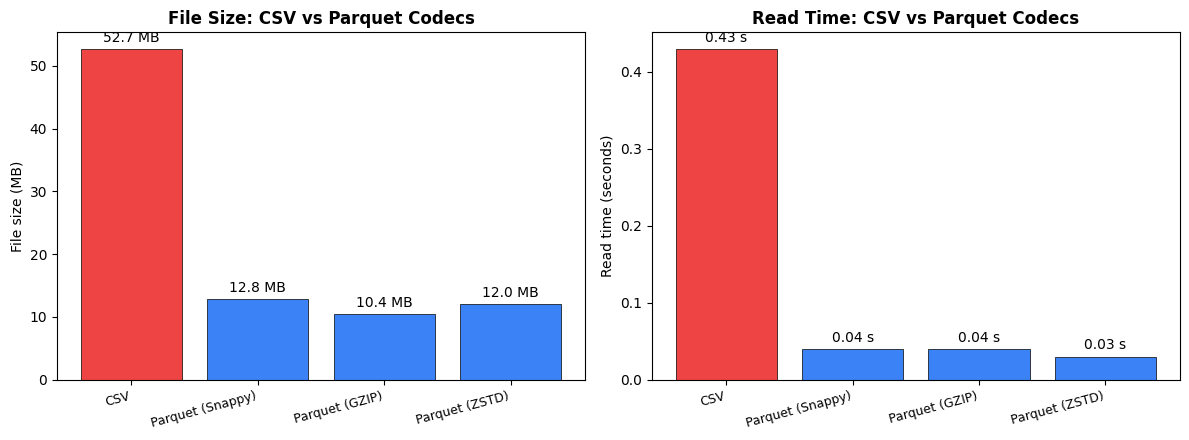

In [13]:
# Visualise the comparison
import matplotlib.pyplot as plt

labels  = [r["Format"] for r in results]
sizes   = [r["File size (MB)"] for r in results]
times   = [r["Read time (s)"] for r in results]
colors  = ["#ef4444", "#3b82f6", "#3b82f6", "#3b82f6"]  # red for CSV, blue for Parquet

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

bars1 = ax1.bar(labels, sizes, color=colors, edgecolor="black", linewidth=0.5)
ax1.set_ylabel("File size (MB)")
ax1.set_title("File Size: CSV vs Parquet Codecs", fontweight="bold")
ax1.bar_label(bars1, fmt="%.1f MB", padding=3)
plt.setp(ax1.get_xticklabels(), rotation=15, ha="right", fontsize=9)

bars2 = ax2.bar(labels, times, color=colors, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("Read time (seconds)")
ax2.set_title("Read Time: CSV vs Parquet Codecs", fontweight="bold")
ax2.bar_label(bars2, fmt="%.2f s", padding=3)
plt.setp(ax2.get_xticklabels(), rotation=15, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

The chart tells the whole story in one glance:

- **File size:** every Parquet codec beats CSV by 4–5x — same 1M rows, a fraction of
  the storage cost. At scale (terabytes), that's a meaningful cloud bill difference.
- **Read time:** Parquet is significantly faster — columnar reads mean less I/O,
  and the types are already encoded so no parsing overhead.
- **GZIP** is the smallest but slowest to read — good for cold archives.
- **ZSTD** hits the sweet spot: near-Snappy speed, near-GZIP size.
- **Snappy** is the safe default: fast to read, fast to write, good compression.

In [15]:
# Column-selection speedup — Parquet's biggest practical advantage
# Query: what's the average temperature per station?
# We time BOTH steps separately: loading the data, AND computing the answer.

# ── CSV: must read ALL row bytes even though we only need two columns ──────────
t0 = time.perf_counter()
df_csv = pd.read_csv("data/weather_large.csv", usecols=["station_id", "temp_c"])
csv_load_time = time.perf_counter() - t0

t0 = time.perf_counter()
csv_result = df_csv.groupby("station_id")["temp_c"].mean().round(2)
csv_compute_time = time.perf_counter() - t0

csv_total = csv_load_time + csv_compute_time

# ── Parquet: physically reads ONLY the two columns from disk (columnar magic) ──
t0 = time.perf_counter()
df_pq = pd.read_parquet("data/weather_large_snappy.parquet", columns=["station_id", "temp_c"])
pq_load_time = time.perf_counter() - t0

t0 = time.perf_counter()
pq_result = df_pq.groupby("station_id")["temp_c"].mean().round(2)
pq_compute_time = time.perf_counter() - t0

pq_total = pq_load_time + pq_compute_time

# ── Report: load time, compute time, AND total time to answer the question ────
print(f"{'':10s} {'load':>8s}  {'compute':>8s}  {'TOTAL':>8s}")
print(f"{'CSV':10s} {csv_load_time:>7.3f}s {csv_compute_time:>7.3f}s {csv_total:>7.3f}s")
print(f"{'Parquet':10s} {pq_load_time:>7.3f}s {pq_compute_time:>7.3f}s {pq_total:>7.3f}s")
print()
print(f"Load-only speedup:        {csv_load_time / pq_load_time:.1f}x faster")
print(f"Total (load+answer) speedup: {csv_total / pq_total:.1f}x faster")
print()
print("Average temp by station (Parquet):")
print(pq_result)
print()
# Values match within rounding tolerance — dtypes differ (float64 vs float32),
# which is exactly the type-preservation difference between CSV and Parquet
values_match = (csv_result - pq_result).abs().max() < 0.01
print(f"Both formats agree on the answer: {values_match}")

               load   compute     TOTAL
CSV          0.171s   0.021s   0.191s
Parquet      0.018s   0.033s   0.051s

Load-only speedup:        9.7x faster
Total (load+answer) speedup: 3.7x faster

Average temp by station (Parquet):
station_id
ANK-002    12.03
ANT-005    12.00
BUR-004    12.01
IST-001    11.98
IZM-003    12.02
Name: temp_c, dtype: float32

Both formats agree on the answer: True


Even when CSV uses `usecols=` to skip columns at the Python level, it still reads
every byte from disk first — Pandas can't skip bytes in the middle of a row-oriented
file. Parquet physically skips the columns you don't request. **That's the columnar
advantage made concrete.**

### Writing Parquet

```python
# Default (Snappy) — the everyday choice
df.to_parquet("output.parquet", index=False)

# Explicit codec choices
df.to_parquet("output.parquet", compression="snappy", index=False)  # fast pipeline
df.to_parquet("archive.parquet", compression="gzip",   index=False)  # cold storage
df.to_parquet("output.parquet", compression="zstd",    index=False)  # best modern choice

# Write specific columns only
df[["station_id", "temp_c", "date"]].to_parquet("slim.parquet", index=False)
```

**When to use Parquet:**
- Data pipelines and ETL (always)
- Data lakes (S3, GCS, ADLS)
- BigQuery / Snowflake / Redshift staging
- Anything Spark reads or writes
- Anywhere you query a subset of columns repeatedly

**When NOT to use Parquet:**
- Sharing with non-engineers who need Excel/CSV
- Very small datasets (CSV overhead doesn't matter at 500 rows)
- Streaming single records (use JSON or Avro)

---
## 6. Format decision guide

A one-page cheat sheet for the question *"which format should I use?"*

| Situation | Format | Why |
|-----------|--------|-----|
| Sending data to a client / Excel | CSV | Universal, human-readable |
| Consuming a REST API | JSON | APIs speak JSON |
| Storing data with nested fields | JSON | Handles hierarchy naturally |
| Data pipeline between systems | Parquet | Fast, typed, compressed |
| Staging data in a warehouse | Parquet | BigQuery/Snowflake expect it |
| Archiving large historical data | Parquet (GZIP) | Smallest file size |
| Hot data read thousands of times | Parquet (Snappy/ZSTD) | Fastest reads |
| Quick one-off data dump | CSV | Simple, no dependencies |
| ML feature store | Parquet | Columnar reads, typed, fast |

**The rule of thumb:** if a human needs to open it → CSV. If an API produces it →
JSON. If a machine processes it → Parquet.

---
## 7. Data profiling

Validation (Session 7) lets you check data against *rules you already know*.
But how do you know what rules to write if you've never seen the dataset before?

**Data profiling** is the answer — an automated summary of a dataset's shape,
types, distributions, and quality. You run it once on a new dataset and get a
complete picture in seconds.

Think of it like a medical checkup: before prescribing treatment (validation
rules, cleaning steps), the doctor runs basic diagnostics to see what's there.

The three things profiling tells you:

1. **Structure** — how many rows, columns, what types?
2. **Quality** — nulls, duplicates, cardinality
3. **Distribution** — ranges, means, modes — do the numbers make sense?

In [16]:
# Load the small weather dataset for profiling
df = pd.read_parquet("data/weather_large_snappy.parquet")

# ── Structure ──────────────────────────────────────────────────────────────────
print("=" * 50)
print("  STRUCTURE")
print("=" * 50)
print(f"  Rows:       {df.shape[0]:,}")
print(f"  Columns:    {df.shape[1]}")
print(f"  Memory:     {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print(df.dtypes)

  STRUCTURE
  Rows:       1,000,000
  Columns:    7
  Memory:     126.3 MB

timestamp       datetime64[us]
station_id              object
temp_c                 float32
humidity_pct             int16
wind_kmh               float32
pressure_hpa           float32
condition               object
dtype: object


In [17]:
# ── Quality ────────────────────────────────────────────────────────────────────
print("=" * 50)
print("  QUALITY")
print("=" * 50)

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
unique_vals = df.nunique()

quality = pd.DataFrame({
    "nulls":      null_counts,
    "null_%":     null_pct,
    "unique":     unique_vals,
    "cardinality": (unique_vals / len(df) * 100).round(2),
})
print(quality)
print()
print(f"  Duplicate rows: {df.duplicated().sum():,}")

  QUALITY
              nulls  null_%   unique  cardinality
timestamp         0     0.0  1000000       100.00
station_id        0     0.0        5         0.00
temp_c            0     0.0     5864         0.59
humidity_pct      0     0.0       80         0.01
wind_kmh          0     0.0    10606         1.06
pressure_hpa      0     0.0     1004         0.10
condition         0     0.0        5         0.00

  Duplicate rows: 0


In [18]:
# ── Distribution ───────────────────────────────────────────────────────────────
print("=" * 50)
print("  DISTRIBUTION — numeric columns")
print("=" * 50)
print(df.describe().round(2))
print()

  DISTRIBUTION — numeric columns
                 timestamp      temp_c  humidity_pct    wind_kmh  pressure_hpa
count              1000000  1000000.00    1000000.00  1000000.00    1000000.00
mean   2073-01-14 07:30:00       12.01         59.55       15.01       1013.02
min    2016-01-01 00:00:00      -28.69         20.00        0.00        957.90
25%    2044-07-08 15:45:00        6.62         40.00        4.32       1004.90
50%    2073-01-14 07:30:00       12.01         60.00       10.41       1013.00
75%    2101-07-23 23:15:00       17.41         80.00       20.81       1021.10
max    2130-01-29 15:00:00       48.87         99.00      230.75       1076.70
std                    NaN        8.00         23.10       15.00         12.00



In [19]:
print("=" * 50)
print("  DISTRIBUTION — categorical columns")
print("=" * 50)
for col in ["station_id", "condition"]:
    print(f"\n  {col}:")
    print(df[col].value_counts().to_string())

  DISTRIBUTION — categorical columns

  station_id:
station_id
IZM-003    200350
IST-001    200255
ANK-002    199963
BUR-004    199960
ANT-005    199472

  condition:
condition
rainy     200675
stormy    200287
foggy     199939
sunny     199631
cloudy    199468


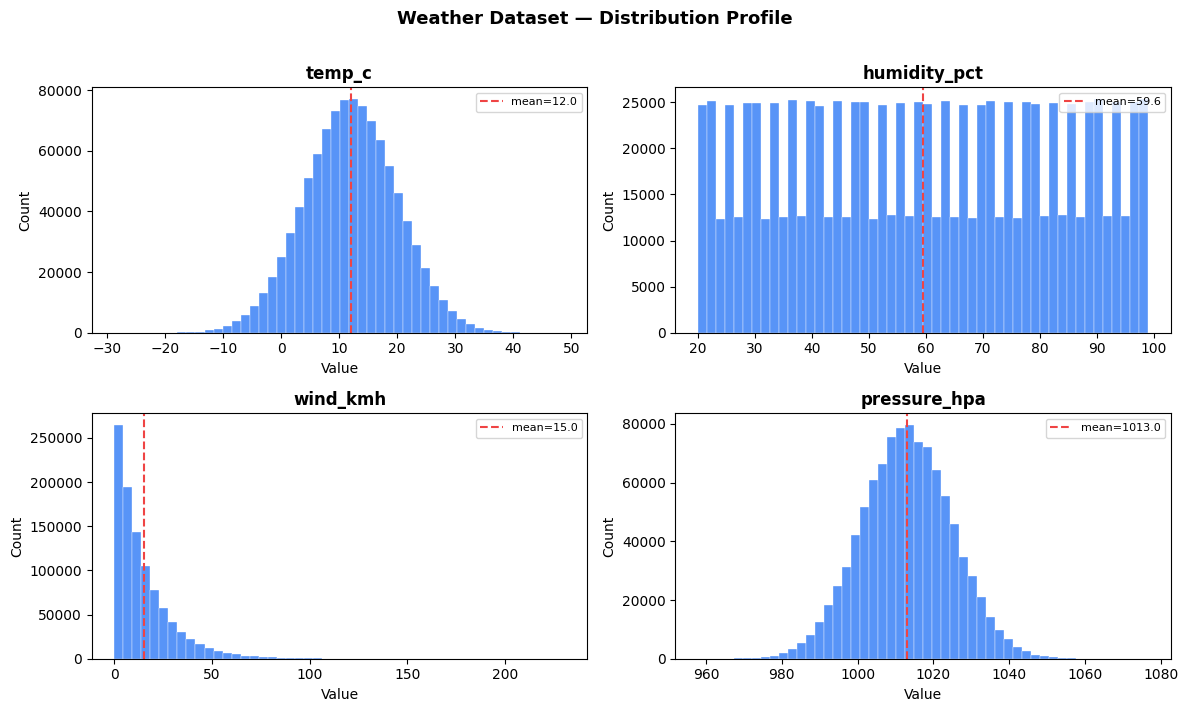

In [20]:
# ── Visual profile ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

numeric_cols = ["temp_c", "humidity_pct", "wind_kmh", "pressure_hpa"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color="#3b82f6", edgecolor="white",
                 linewidth=0.3, alpha=0.85)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    stats = df[col].describe()
    axes[i].axvline(stats["mean"], color="#ef4444", linestyle="--",
                    linewidth=1.5, label=f"mean={stats['mean']:.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle("Weather Dataset — Distribution Profile", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Reading a distribution profile:**

- **temp_c** — bell-shaped around 12°C with wide spread (−20 to 40°C). Looks realistic
  for a multi-city, multi-year dataset. No obvious outliers.
- **humidity_pct** — roughly uniform between 20–100%. Uniform distributions in sensor
  data sometimes signal synthetic data or a malfunctioning sensor range.
- **wind_kmh** — right-skewed (most readings are low, occasional highs). This is
  exactly what real wind data looks like — exponential distribution.
- **pressure_hpa** — tight bell around 1013 hPa (sea-level standard). The spread
  reflects real atmospheric variation.

**Profile before you validate.** Once you've seen these distributions, writing the
Session 7 rules becomes obvious: `temp_c` between −40 and 55, `humidity_pct`
between 0 and 100, `pressure_hpa` between 870 and 1085.

---
## 8. Exercises

### Exercise 1 — CSV round-trip with type control

Load `data/weather_readings.csv`, fix the `date` column to a proper datetime,
cast `temp_c` to `float32` and `humidity_pct` to `int16`, then save it back out
as a new CSV called `weather_clean.csv`. Reload it and confirm the shape is unchanged.

*(Why `float32` and `int16`? Try `df.memory_usage(deep=True).sum()` before and
after — you'll see the memory drop. Type discipline matters at scale.)*

In [ ]:
# Your code here


<details>
<summary><b>Show solution</b></summary>

```python
df = pd.read_csv("data/weather_readings.csv")
df["date"] = pd.to_datetime(df["date"])
df["temp_c"] = df["temp_c"].astype("float32")
df["humidity_pct"] = df["humidity_pct"].astype("int16")

before = pd.read_csv("data/weather_readings.csv").memory_usage(deep=True).sum()
after  = df.memory_usage(deep=True).sum()
print(f"Memory before type fixes: {before:,} bytes")
print(f"Memory after  type fixes: {after:,} bytes")
print(f"Saved: {(before - after) / before * 100:.1f}%")

df.to_csv("weather_clean.csv", index=False)
check = pd.read_csv("weather_clean.csv")
print("Reloaded shape:", check.shape)
```

Note that reloading from CSV *loses the type information again* — `date` reverts to
`object`, `float32` becomes `float64`. This is why Parquet matters: it preserves
types across write/read cycles.
</details>

### Exercise 2 — Flatten a tricky nested JSON

The `weather_stations.json` file has station `location` as a nested object
(`{"city": ..., "lat": ..., "lon": ...}`). Flatten the file so that `lat` and
`lon` become top-level columns alongside `station_id` and each reading.

Expected columns: `station_id`, `city`, `lat`, `lon`, `elevation_m`, `date`,
`temp_c`, `humidity_pct`, `wind_kmh`, `condition`

In [ ]:
# Your code here


<details>
<summary><b>Show solution</b></summary>

```python
with open("data/weather_stations.json") as f:
    raw = json.load(f)

records = []
for entry in raw:
    st = entry["station"]
    for reading in entry["readings"]:
        records.append({
            "station_id":  st["id"],
            "city":        st["location"]["city"],   # nested one level
            "lat":         st["location"]["lat"],    # nested one level
            "lon":         st["location"]["lon"],    # nested one level
            "elevation_m": st["elevation_m"],
            **reading,
        })

df = pd.DataFrame(records)
print(df.columns.tolist())
print(df.shape)
df.head()
```

The key move is accessing `st["location"]["city"]` — two levels of dict access —
and then using `**reading` to unpack all reading fields at once instead of naming
them one by one.
</details>

### Exercise 3 — Parquet codec comparison (write side)

Take `data/weather_readings.csv` (the small 150-row file), write it to Parquet
with all three codecs (`snappy`, `gzip`, `zstd`), and print a table comparing
file sizes. Then read each back and verify the row count is still 150.

*(The size differences will be small at 150 rows — compression shines at scale.
The exercise is about getting comfortable with the write API before you need it
on a 1M-row file.)*

In [ ]:
# Your code here


<details>
<summary><b>Show solution</b></summary>

```python
import os

df = pd.read_csv("data/weather_readings.csv")

codecs = ["snappy", "gzip", "zstd"]
for codec in codecs:
    path = f"weather_readings_{codec}.parquet"
    df.to_parquet(path, compression=codec, index=False)
    size_kb = os.path.getsize(path) / 1024
    reloaded = pd.read_parquet(path)
    print(f"{codec:6s} → {size_kb:.1f} KB  |  rows: {len(reloaded)}")
```

At 150 rows the differences are measured in kilobytes — barely noticeable.
Run the same code on `weather_large.csv` and the gap becomes 10+ MB between codecs.
Always benchmark on representative data sizes before choosing a codec for production.
</details>

### Exercise 4 — Profile a mystery column

Load `data/weather_large_snappy.parquet` and profile **only the `condition`
column**. Answer these questions using code:

1. How many unique values are there?
2. What is the most common condition, and what percentage of rows is it?
3. Are there any nulls?
4. Does the distribution look uniform or skewed?

*(Hint: `.value_counts(normalize=True)` gives you proportions directly.)*

In [ ]:
# Your code here


<details>
<summary><b>Show solution</b></summary>

```python
df = pd.read_parquet(
    "data/weather_large_snappy.parquet",
    columns=["condition"]   # only load the column you need — columnar advantage
)

print("Unique values:", df["condition"].nunique())
print("Nulls:", df["condition"].isnull().sum())
print()
print("Distribution:")
vc = df["condition"].value_counts(normalize=True).mul(100).round(2)
print(vc.to_string())
print()
print("Most common:", vc.index[0], f"({vc.iloc[0]}%)")
```

Note `columns=["condition"]` in `read_parquet` — at 1M rows, reading only the
column you need is noticeably faster than loading the whole file and then slicing.
This is the columnar advantage in your day-to-day workflow.
</details>

---
## 9. Recap & what's next

**What you learned:**

| | CSV | JSON | Parquet |
|---|---|---|---|
| **Storage** | Row-based | Hierarchical | Columnar |
| **Typed?** | No — everything is text | Partial | Yes — full type preservation |
| **Compression** | None | None (by default) | Snappy / GZIP / ZSTD |
| **Speed (large data)** | Slow | Slow | Fast |
| **Human-readable?** | Yes | Yes | No |
| **Best for** | Sharing, Excel, legacy | APIs, nested data | Pipelines, warehouses, lakes |

**Parquet internals you now understand:**
- **Columnar storage** → only reads columns you ask for
- **Dictionary encoding** → low-cardinality strings stored as integers
- **RLE / Delta encoding** → repeated values and sequences stored compactly
- **Row groups + statistics** → query engines skip irrelevant chunks entirely
- **Codecs** → Snappy (fast), GZIP (small), ZSTD (best of both)

**Data profiling** is the diagnostic step before validation — run it once on any
new dataset to understand its structure, quality, and distributions before writing
a single expectation.

**Coming up — Week 5: SQL Fundamentals.** You've been processing data with Python
and Pandas. SQL is the other half of the data engineer's toolkit — and with DuckDB
you'll be able to run SQL directly on your Parquet files, no database server needed.

---

*Modern Data Engineering · Ameer Ul Islam · A Depthware Course*